# 03 - Entrenamiento y evaluación de modelos

## Predicción del riesgo de rotura de stock en un entorno logístico

Este notebook entrena y compara varios modelos de clasificación binaria para predecir la variable `stockout_risk`.

El objetivo no es maximizar métricas artificialmente, sino construir una evaluación realista y defendible. Por ello:

- Se utiliza el dataset procesado en `02_feature_engineering.ipynb`.
- Se excluyen variables que pueden introducir leakage.
- Se realiza una partición temporal entre entrenamiento y test.
- Se comparan modelos de distinta complejidad.
- Se exportan métricas, gráficos y el mejor modelo para los siguientes apartados del proyecto.

## 1. Carga de librerías


In [7]:
import os
import json
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

RANDOM_STATE = 42

## 2. Configuración de rutas

La ruta principal esperada es `../data/processed/stockout_dataset.csv`.

Si el notebook se ejecuta desde otro entorno, revisa la variable `PROCESSED_DATA_PATH`.

In [8]:
PROCESSED_DATA_PATH = "../data/processed/stockout_dataset.csv"

OUTPUT_DIR = "../outputs"
FIGURES_DIR = "../outputs/figures"
METRICS_DIR = "../outputs/metrics"
MODELS_DIR = "../models"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("Processed data path:", PROCESSED_DATA_PATH)
print("Outputs directory:", OUTPUT_DIR)

Processed data path: ../data/processed/stockout_dataset.csv
Outputs directory: ../outputs


## 3. Carga del dataset procesado

In [9]:
df = pd.read_csv(PROCESSED_DATA_PATH)

print("Dimensiones del dataset:", df.shape)
display(df.head())

Dimensiones del dataset: (4472500, 25)


,date,store_id,item_id,sales,price,promo,weekday,month,year,quarter,week,day,sales_lag_7,sales_lag_14,sales_lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_30,trend_7_30,stock_estimated,safety_stock,lead_time_days,future_demand_7d,stockout_risk
0,2019-01-31,store_1,item_1,50,21.3000,0,3,1,2019,1,5,31,40.0000,46.0000,41.0000,42.7143,42.1429,42.7667,6.2515,-0.0524,299.3667,9.3773,4,338.0000,1
1,2019-02-01,store_1,item_1,41,21.3000,0,4,2,2019,1,5,1,38.0000,40.0000,53.0000,44.1429,42.4286,43.0667,6.3785,1.0762,344.5333,9.5677,1,336.0000,1
2,2019-02-02,store_1,item_1,34,21.3000,0,5,2,2019,1,5,2,34.0000,33.0000,39.0000,44.5714,42.5000,42.6667,6.1045,1.9048,341.3333,9.1567,2,352.0000,1
3,2019-02-03,store_1,item_1,34,21.3000,0,6,2,2019,1,5,3,40.0000,39.0000,35.0000,44.5714,42.5714,42.5000,6.2739,2.0714,212.5000,9.4109,1,375.0000,1
4,2019-02-04,store_1,item_1,64,17.0400,1,0,2,2019,1,6,4,44.0000,38.0000,51.0000,43.7143,42.2143,42.4667,6.3176,1.2476,297.2667,9.4765,1,350.0000,1


## 4. Revisión básica del dataset

Antes de entrenar modelos se revisan columnas, tipos de datos y distribución de la variable objetivo.

In [10]:
print("Columnas disponibles:")
print(df.columns.tolist())

print("\nTipos de datos:")
display(df.dtypes)

print("\nValores nulos por columna:")
display(df.isna().sum().sort_values(ascending=False).head(20))

target = "stockout_risk"

print("\nDistribución del target:")
display(
    pd.concat(
        [
            df[target].value_counts().rename("count"),
            df[target].value_counts(normalize=True).rename("percentage")
        ],
        axis=1
    )
)

Columnas disponibles:
['date', 'store_id', 'item_id', 'sales', 'price', 'promo', 'weekday', 'month', 'year', 'quarter', 'week', 'day', 'sales_lag_7', 'sales_lag_14', 'sales_lag_30', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'rolling_std_30', 'trend_7_30', 'stock_estimated', 'safety_stock', 'lead_time_days', 'future_demand_7d', 'stockout_risk']

Tipos de datos:


date                    str
store_id                str
item_id                 str
sales                 int64
price               float64
promo                 int64
weekday               int64
month                 int64
year                  int64
quarter               int64
week                  int64
day                   int64
sales_lag_7         float64
sales_lag_14        float64
sales_lag_30        float64
rolling_mean_7      float64
rolling_mean_14     float64
rolling_mean_30     float64
rolling_std_30      float64
trend_7_30          float64
stock_estimated     float64
safety_stock        float64
lead_time_days        int64
future_demand_7d    float64
stockout_risk         int64
dtype: object


Valores nulos por columna:


date               0
store_id           0
item_id            0
sales              0
price              0
promo              0
weekday            0
month              0
year               0
quarter            0
week               0
day                0
sales_lag_7        0
sales_lag_14       0
sales_lag_30       0
rolling_mean_7     0
rolling_mean_14    0
rolling_mean_30    0
rolling_std_30     0
trend_7_30         0
dtype: int64


Distribución del target:


,count,percentage
stockout_risk,,
1,2589460,0.5790
0,1883040,0.4210


## 5. Control de leakage

No se deben usar como variables predictoras aquellas columnas que formen parte directa de la construcción del target o que contengan información futura.

Columnas excluidas:

- `stockout_risk`: variable objetivo.
- `future_demand_7d`: demanda futura usada para construir el target.
- `stock_estimated`: variable simulada relacionada con la regla de stockout.
- `safety_stock`: variable simulada relacionada con la regla de stockout.

Estas variables pueden utilizarse para análisis de negocio, pero no para entrenar el modelo predictivo.

In [11]:
leakage_columns = [
    "stockout_risk",
    "future_demand_7d",
    "stock_estimated",
    "safety_stock"
]

existing_leakage_columns = [col for col in leakage_columns if col in df.columns]
print("Columnas identificadas como posibles fuentes de leakage:")
print(existing_leakage_columns)

Columnas identificadas como posibles fuentes de leakage:
['stockout_risk', 'future_demand_7d', 'stock_estimated', 'safety_stock']


## 6. Selección de variables predictoras

Se utilizan variables disponibles en el momento de realizar la predicción:

- Ventas actuales e históricas.
- Precio.
- Promoción.
- Variables temporales.
- Lags.
- Medias móviles.
- Volatilidad de demanda.
- Tendencia.
- Lead time simulado.

La lista se valida contra las columnas existentes del dataset para evitar errores de ejecución.

In [12]:
model_features = [
    "sales",
    "price",
    "promo",
    "weekday",
    "month",
    "year",
    "quarter",
    "week",
    "day",
    "sales_lag_7",
    "sales_lag_14",
    "sales_lag_30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "rolling_std_30",
    "trend_7_30",
    "lead_time_days"
]

available_features = [col for col in model_features if col in df.columns]
missing_features = [col for col in model_features if col not in df.columns]

print("Features disponibles:", len(available_features))
print(available_features)

if missing_features:
    print("\nFeatures no encontradas en el dataset:")
    print(missing_features)

for col in available_features:
    if col in existing_leakage_columns:
        raise ValueError(f"La columna {col} no debe usarse como feature porque puede introducir leakage.")

X = df[available_features].copy()
y = df[target].copy()

print("\nDimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Features disponibles: 18
['sales', 'price', 'promo', 'weekday', 'month', 'year', 'quarter', 'week', 'day', 'sales_lag_7', 'sales_lag_14', 'sales_lag_30', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'rolling_std_30', 'trend_7_30', 'lead_time_days']

Dimensiones de X: (4472500, 18)
Dimensiones de y: (4472500,)


## 7. Partición temporal train/test

El problema tiene una dimensión temporal, por lo que se utiliza una partición cronológica:

- Train: primeras observaciones en el tiempo.
- Test: observaciones más recientes.

Este enfoque es más realista que un split aleatorio, porque en producción el modelo se entrenaría con histórico y se aplicaría sobre datos futuros.

In [13]:
if "date" not in df.columns:
    raise ValueError("El dataset debe contener una columna 'date' para realizar split temporal.")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

cutoff_date = df["date"].quantile(0.8)

train_df = df[df["date"] <= cutoff_date].copy()
test_df = df[df["date"] > cutoff_date].copy()

X_train = train_df[available_features]
y_train = train_df[target]

X_test = test_df[available_features]
y_test = test_df[target]

print("Fecha mínima train:", train_df["date"].min())
print("Fecha máxima train:", train_df["date"].max())
print("Fecha mínima test:", test_df["date"].min())
print("Fecha máxima test:", test_df["date"].max())

print("\nDimensiones train:", X_train.shape)
print("Dimensiones test:", X_test.shape)

print("\nDistribución target en train:")
display(y_train.value_counts(normalize=True).rename("train_target_distribution"))

print("\nDistribución target en test:")
display(y_test.value_counts(normalize=True).rename("test_target_distribution"))

Fecha mínima train: 2019-01-31 00:00:00
Fecha máxima train: 2023-01-01 00:00:00
Fecha mínima test: 2023-01-02 00:00:00
Fecha máxima test: 2023-12-24 00:00:00

Dimensiones train: (3580000, 18)
Dimensiones test: (892500, 18)

Distribución target en train:


stockout_risk
1   0.5797
0   0.4203
Name: train_target_distribution, dtype: float64


Distribución target en test:


stockout_risk
1   0.5762
0   0.4238
Name: test_target_distribution, dtype: float64

## 8. Definición de modelos

Se comparan tres enfoques:

1. **Logistic Regression**: baseline interpretable.
2. **Random Forest**: modelo robusto basado en árboles.
3. **XGBoost**: modelo avanzado de boosting.

Para evitar tiempos excesivos, Random Forest se configura con una profundidad limitada. 

In [17]:
models = {}

models["Logistic Regression"] = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

models["Random Forest"] = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

models["XGBoost"] = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Modelos definidos:")
print(list(models.keys()))

Modelos definidos:
['Logistic Regression', 'Random Forest', 'XGBoost']


## 9. Función de evaluación

La evaluación utiliza métricas adecuadas para clasificación binaria:

- Accuracy.
- Precision.
- Recall.
- F1-score.
- ROC-AUC.

En este problema, el recall es especialmente relevante porque interesa detectar el mayor número posible de situaciones de riesgo de stockout. No obstante, se analiza junto con precision y F1 para controlar el exceso de falsas alertas.

In [18]:
def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    }

    return metrics, y_pred, y_proba

## 10. Entrenamiento y comparación de modelos

In [19]:
results = []
predictions = {}

for model_name, model in models.items():
    print(f"Entrenando {model_name}...")
    model.fit(X_train, y_train)

    metrics, y_pred, y_proba = evaluate_model(model_name, model, X_test, y_test)

    results.append(metrics)
    predictions[model_name] = {
        "y_pred": y_pred,
        "y_proba": y_proba,
        "model": model
    }

    print(metrics)
    print("-" * 80)

results_df = pd.DataFrame(results).sort_values("f1_score", ascending=False).reset_index(drop=True)
display(results_df)

Entrenando Logistic Regression...
{'model': 'Logistic Regression', 'accuracy': 0.572519887955182, 'precision': 0.6351239131142736, 'recall': 0.6067330090102703, 'f1_score': 0.6206039295395649, 'roc_auc': 0.5890430379967982}
--------------------------------------------------------------------------------
Entrenando Random Forest...
{'model': 'Random Forest', 'accuracy': 0.5898778711484594, 'precision': 0.6726833540644669, 'recall': 0.5615124965487204, 'f1_score': 0.6120910378038338, 'roc_auc': 0.622718876003358}
--------------------------------------------------------------------------------
Entrenando XGBoost...
{'model': 'XGBoost', 'accuracy': 0.5902879551820728, 'precision': 0.6730217636267124, 'recall': 0.5620802563474379, 'f1_score': 0.612568418331345, 'roc_auc': 0.6237978693900981}
--------------------------------------------------------------------------------


,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.5725,0.6351,0.6067,0.6206,0.5890
1,XGBoost,0.5903,0.6730,0.5621,0.6126,0.6238
2,Random Forest,0.5899,0.6727,0.5615,0.6121,0.6227


## 11. Guardado de métricas

In [20]:
metrics_path = os.path.join(METRICS_DIR, "model_metrics.csv")
results_df.to_csv(metrics_path, index=False)

print(f"Métricas guardadas en: {metrics_path}")

Métricas guardadas en: ../outputs/metrics\model_metrics.csv


## 12. Selección del modelo final

La selección se realiza principalmente por F1-score, ya que equilibra precision y recall.


In [21]:
best_model_name = results_df.iloc[0]["model"]
best_model = predictions[best_model_name]["model"]

print("Modelo seleccionado:", best_model_name)
display(results_df.iloc[[0]])

model_path = os.path.join(MODELS_DIR, "best_stockout_model.pkl")
joblib.dump(best_model, model_path)

features_path = os.path.join(MODELS_DIR, "model_features.json")
with open(features_path, "w", encoding="utf-8") as f:
    json.dump(available_features, f, ensure_ascii=False, indent=4)

print(f"Modelo guardado en: {model_path}")
print(f"Features guardadas en: {features_path}")

Modelo seleccionado: Logistic Regression


,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.5725,0.6351,0.6067,0.6206,0.5890


Modelo guardado en: ../models\best_stockout_model.pkl
Features guardadas en: ../models\model_features.json


## 13. Matriz de confusión del modelo final

La matriz de confusión permite analizar:

- Verdaderos negativos.
- Falsos positivos.
- Falsos negativos.
- Verdaderos positivos.

En este proyecto, los falsos negativos son especialmente importantes porque representan casos reales de riesgo de stockout que el modelo no detecta.

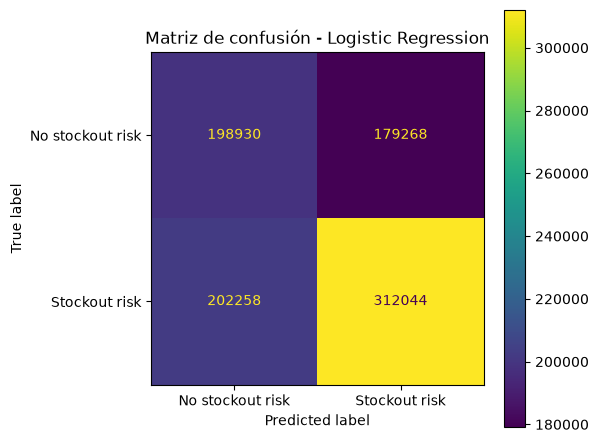

Matriz de confusión guardada en: ../outputs/figures\confusion_matrix_best_model.png

Classification report:
                  precision    recall  f1-score   support

No stockout risk       0.50      0.53      0.51    378198
   Stockout risk       0.64      0.61      0.62    514302

        accuracy                           0.57    892500
       macro avg       0.57      0.57      0.57    892500
    weighted avg       0.58      0.57      0.57    892500



In [22]:
best_y_pred = predictions[best_model_name]["y_pred"]

cm = confusion_matrix(y_test, best_y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No stockout risk", "Stockout risk"])
disp.plot(ax=ax, values_format="d")
plt.title(f"Matriz de confusión - {best_model_name}")
plt.tight_layout()

confusion_matrix_path = os.path.join(FIGURES_DIR, "confusion_matrix_best_model.png")
plt.savefig(confusion_matrix_path, dpi=150)
plt.show()

print(f"Matriz de confusión guardada en: {confusion_matrix_path}")

print("\nClassification report:")
print(classification_report(y_test, best_y_pred, target_names=["No stockout risk", "Stockout risk"]))

## 14. Curvas ROC

La curva ROC permite comparar la capacidad de separación de clases de los modelos.

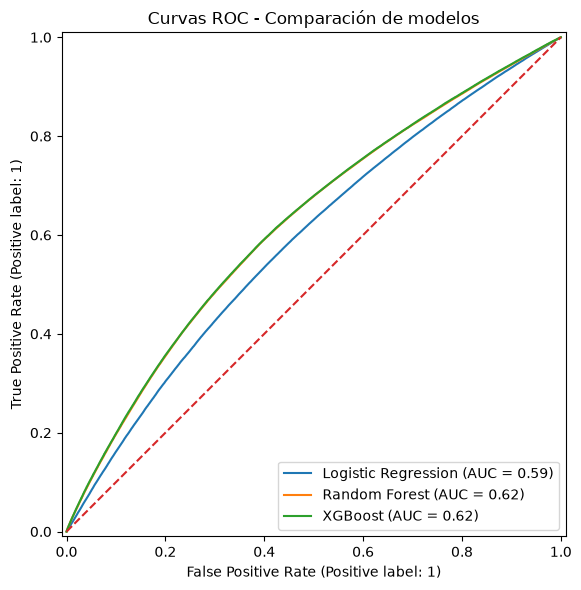

Curvas ROC guardadas en: ../outputs/figures\roc_curves_models.png


In [23]:
plt.figure(figsize=(8, 6))

for model_name, model_info in predictions.items():
    y_proba = model_info["y_proba"]
    if y_proba is not None:
        RocCurveDisplay.from_predictions(
            y_test,
            y_proba,
            name=model_name,
            ax=plt.gca()
        )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curvas ROC - Comparación de modelos")
plt.tight_layout()

roc_curve_path = os.path.join(FIGURES_DIR, "roc_curves_models.png")
plt.savefig(roc_curve_path, dpi=150)
plt.show()

print(f"Curvas ROC guardadas en: {roc_curve_path}")

## 15. Importancia de variables

Si el modelo final permite obtener importancia de variables, se genera una primera visualización. 

,feature,importance
13,rolling_mean_14,1.6194
14,rolling_mean_30,0.9024
12,rolling_mean_7,0.8530
0,sales,0.3797
16,trend_7_30,0.2235
10,sales_lag_14,0.1122
2,promo,0.1075
9,sales_lag_7,0.1038
7,week,0.0675
11,sales_lag_30,0.0559


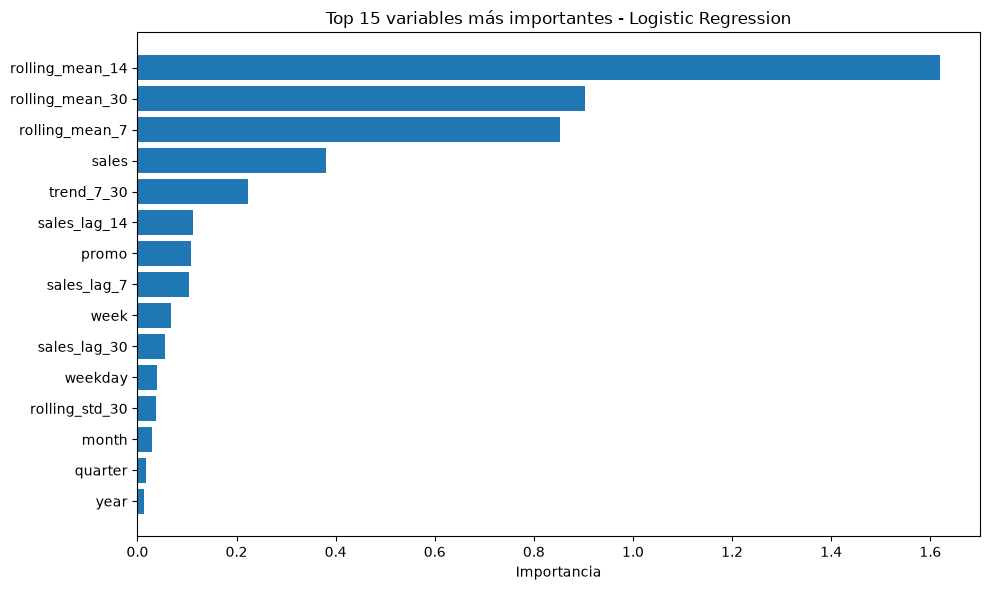

Importancia de variables guardada en: ../outputs/metrics\feature_importance_best_model.csv
Gráfico guardado en: ../outputs/figures\feature_importance_best_model.png


In [24]:
def get_feature_importance(model, feature_names):
    if hasattr(model, "feature_importances_"):
        return model.feature_importances_

    if isinstance(model, Pipeline):
        final_model = model.named_steps.get("model")
        if hasattr(final_model, "coef_"):
            return np.abs(final_model.coef_[0])

    if hasattr(model, "coef_"):
        return np.abs(model.coef_[0])

    return None

importance_values = get_feature_importance(best_model, available_features)

if importance_values is not None:
    importance_df = pd.DataFrame({
        "feature": available_features,
        "importance": importance_values
    }).sort_values("importance", ascending=False)

    display(importance_df.head(20))

    importance_path = os.path.join(METRICS_DIR, "feature_importance_best_model.csv")
    importance_df.to_csv(importance_path, index=False)

    plt.figure(figsize=(10, 6))
    top_importance = importance_df.head(15).sort_values("importance", ascending=True)
    plt.barh(top_importance["feature"], top_importance["importance"])
    plt.title(f"Top 15 variables más importantes - {best_model_name}")
    plt.xlabel("Importancia")
    plt.tight_layout()

    feature_importance_plot_path = os.path.join(FIGURES_DIR, "feature_importance_best_model.png")
    plt.savefig(feature_importance_plot_path, dpi=150)
    plt.show()

    print(f"Importancia de variables guardada en: {importance_path}")
    print(f"Gráfico guardado en: {feature_importance_plot_path}")
else:
    print("El modelo seleccionado no expone importancia de variables de forma directa.")

## 16. Exportación de predicciones para análisis posterior

Se guardan las predicciones del modelo final para utilizarlas en el notebook siguiente:

- Explicabilidad.
- Ajuste de umbral.
- Métricas de negocio.
- Simulación de impacto.

In [25]:
prediction_output = test_df[["date"]].copy()
prediction_output["y_true"] = y_test.values
prediction_output["y_pred"] = best_y_pred

best_y_proba = predictions[best_model_name]["y_proba"]
if best_y_proba is not None:
    prediction_output["y_proba"] = best_y_proba
else:
    prediction_output["y_proba"] = np.nan

optional_id_cols = [col for col in ["store_id", "item_id"] if col in test_df.columns]
prediction_output = pd.concat(
    [
        test_df[optional_id_cols].reset_index(drop=True),
        prediction_output.reset_index(drop=True)
    ],
    axis=1
)

predictions_path = os.path.join(OUTPUT_DIR, "test_predictions_best_model.csv")
prediction_output.to_csv(predictions_path, index=False)

print(f"Predicciones guardadas en: {predictions_path}")
display(prediction_output.head())

Predicciones guardadas en: ../outputs\test_predictions_best_model.csv


,store_id,item_id,date,y_true,y_pred,y_proba
0,store_27,item_5,2023-01-02,1,1,0.5795
1,store_29,item_37,2023-01-02,1,1,0.6115
2,store_46,item_20,2023-01-02,0,1,0.5817
3,store_43,item_8,2023-01-02,1,1,0.5587
4,store_30,item_49,2023-01-02,1,1,0.5874


## 17. Conclusiones del entrenamiento

En esta fase se ha construido una comparación inicial de modelos evitando variables con riesgo de leakage y utilizando una validación temporal.

La interpretación final debe realizarse con cautela:

- Si el rendimiento es moderado, no debe presentarse como una solución cerrada.
- Si el recall es alto, puede tener valor operativo para priorizar alertas.
- Si la precision es limitada, el sistema puede generar falsas alarmas que deberán gestionarse en negocio.
- La decisión final dependerá del coste relativo entre no detectar una rotura de stock y revisar una alerta falsa.

